# Aufgabe 2

## Messen der Daten

Bei der zweiten Aufgabe, sollten wir die Resonanzkurve des Drehpendels bei einer Dämpfung messen, sowie die Phasenverschiebung zwischen der Anregung und Pendelscheibe. Da die Dämpfung über die Spule kommt und diese über den Strom am Channel 1 angesteuert wird, haben wir dort konstant 0.3 A eingestellt. Um herauszufinden, in welchem Bereich die Resonanzkurve circa ihren Peak hat, wurde zuerst in 1V Schritten zwischen 3V und 12V gemessen. Dabei ist aufgefallen, dass der Peak ungefähr bei 11V liegt, weshalb die eigentliche Messung zwischen 9V und 12V stattfand jeweils im Abstand von 0.1V.

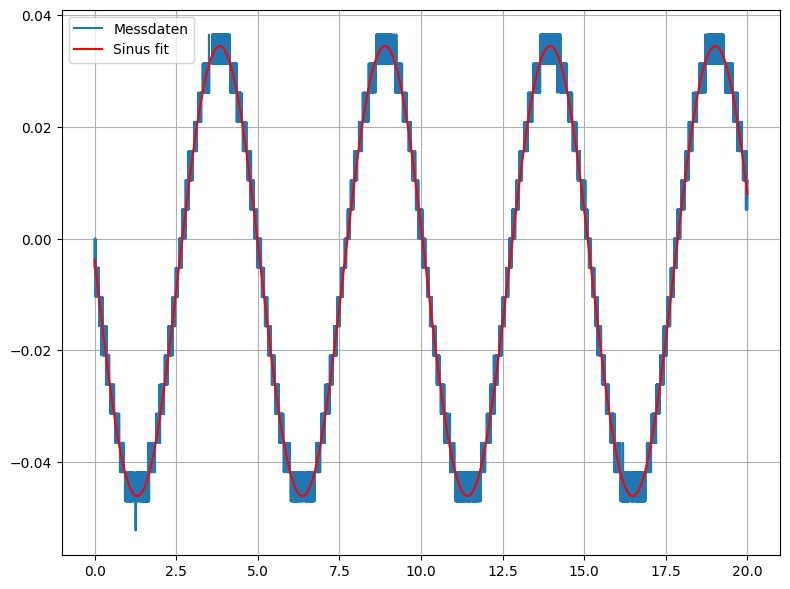

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Konstanten

def sinus_function(x, A, omega, phase, offset):
    return A * np.sin(omega * x + phase) + offset

def estimate_omega_fft(x_data, y_data):
    # Compute sampling interval
    dt = np.mean(np.diff(x_data))
    n = len(x_data)
    f = np.fft.fftfreq(n, d=dt)
    Y = np.fft.fft(y_data - np.mean(y_data))
    idx = np.argmax(np.abs(Y[1:n//2])) + 1  # skip zero freq
    freq = np.abs(f[idx])
    omega = 2 * np.pi * freq
    return omega

def fit_sinus(x_data, y_data):
    A_guess = (np.max(y_data) - np.min(y_data)) / 2
    omega_guess = estimate_omega_fft(x_data, y_data)
    phase_guess = 0
    offset_guess = np.mean(y_data)
    p0 = [A_guess, omega_guess, phase_guess, offset_guess]

    params, params_covariance = curve_fit(
        sinus_function, x_data, y_data, p0=p0, maxfev=10000
    )
    fitted_y = sinus_function(x_data, *params)
    return params, fitted_y


# CSV-Datei laden (bitte Pfad anpassen!)
df = pd.read_csv('M10_Aufgabe_2_CSV_Daten/6V_Aufgabe_2_daten.csv')
df.columns = ['t (s)', 'U1(V)', 'U2(V)']

x = df['t (s)'].values
y = df['U2(V)'].values

params, fitted_y = fit_sinus(x, y)

# Plot
plt.figure(figsize=(8, 6))
plt.plot("t (s)", "U2(V)", data=df, label='Messdaten')
plt.plot(x, fitted_y, 'r-', label='Sinus fit')
#plt.title('a = 0.5R')
#plt.xlabel('z [mm]')
#plt.ylabel('B [mT]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
